In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/train_data.csv")
df.head()

C:\Users\fam-01\AppData\Local\Temp\ipykernel_4392\2693545918.py:1: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/train_data.csv")


,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600


In [4]:
df.shape

(838944, 11)

In [5]:
df['reviewText'].isna().sum()

np.int64(0)

In [6]:
df["review_length"] = df["reviewText"].fillna("").str.len()
df["review_length"].value_counts()

review_length
203     3408
200     3342
201     3311
204     3288
208     3247
        ... 
7585       1
6120       1
4055       1
6082       1
8010       1
Name: count, Length: 6657, dtype: int64

In [7]:
df['review_length'].describe()

count    838944.000000
mean        624.687384
std         684.129474
min         200.000000
25%         277.000000
50%         408.000000
75%         697.000000
max       29146.000000
Name: review_length, dtype: float64

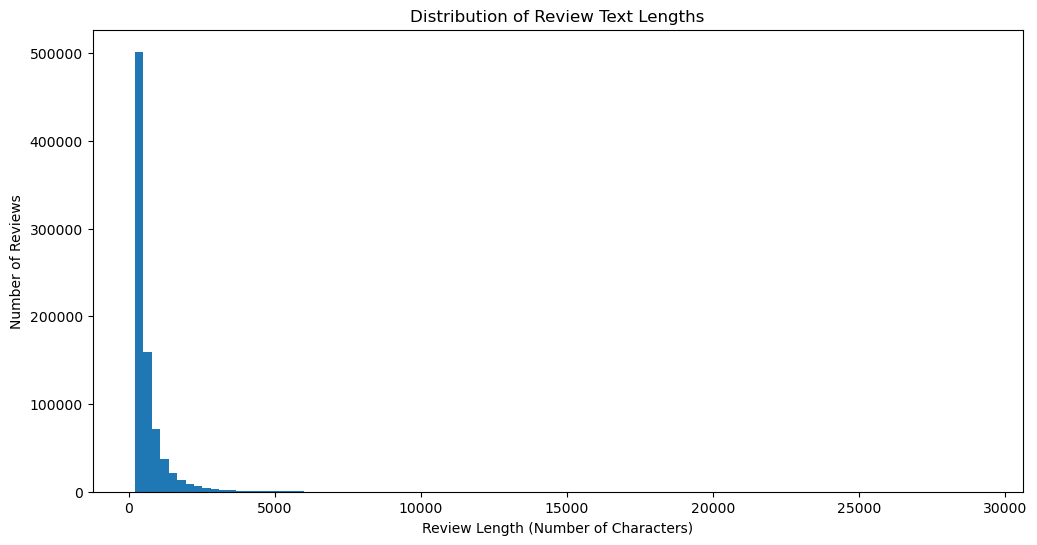

In [8]:
plt.figure(figsize=(12, 6))

plt.hist(df["review_length"], bins=100)

plt.xlabel("Review Length (Number of Characters)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Text Lengths")

plt.show()

In [9]:
df['review_length'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900    1217.000
0.950    1733.000
0.990    3399.000
0.995    4357.000
0.999    7224.114
Name: review_length, dtype: float64

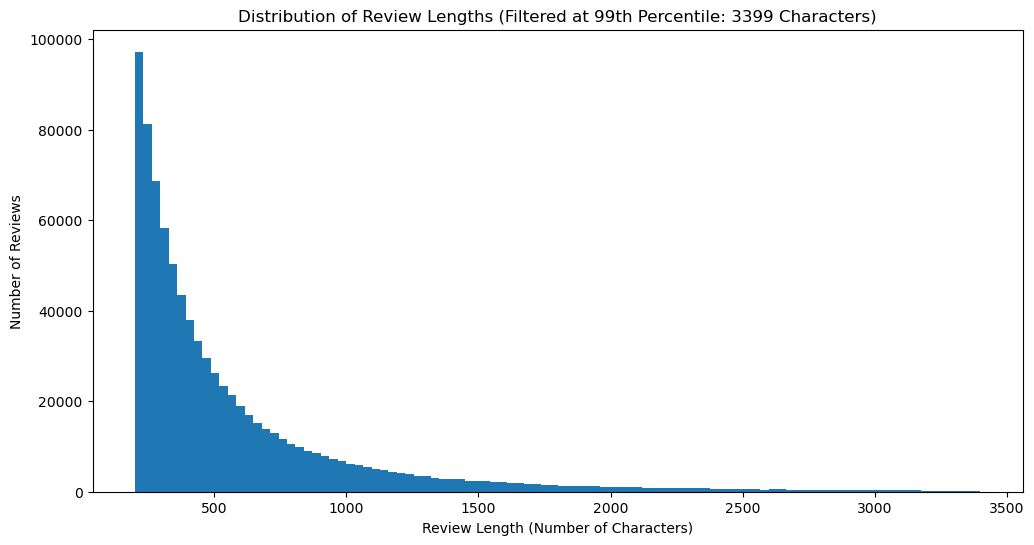

In [10]:
upper_limit = df["review_length"].quantile(0.99)

filtered_lengths = df[df["review_length"] <= upper_limit]["review_length"]

plt.figure(figsize=(12, 6))

plt.hist(filtered_lengths, bins=100)

plt.xlabel("Review Length (Number of Characters)")
plt.ylabel("Number of Reviews")
plt.title(
    f"Distribution of Review Lengths "
    f"(Filtered at 99th Percentile: {upper_limit:.0f} Characters)"
)

plt.show()

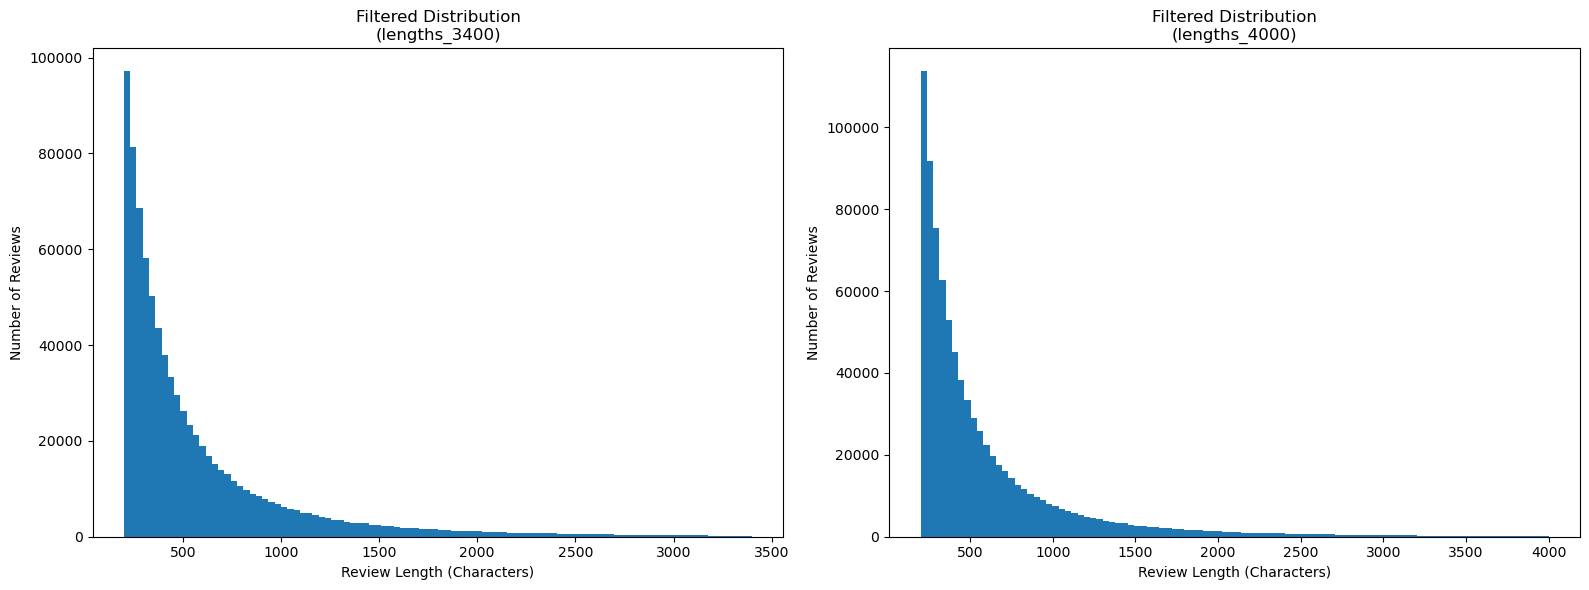

In [11]:
df_new = df.copy()
df_new["review_length"] = df_new["reviewText"].fillna("").str.len()

lengths = df_new["review_length"]

# upper_limit = lengths.quantile(0.99)
# filtered_lengths = lengths[lengths <= upper_limit]

lengths_3400 = lengths[lengths <= 3400]
lengths_4000 = lengths[lengths <= 4000]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(lengths_3400, bins=100)

# axes[0].set_title("Original Distribution")
axes[0].set_title(f"Filtered Distribution\n" f"(lengths_3400)")
axes[0].set_xlabel("Review Length (Characters)")
axes[0].set_ylabel("Number of Reviews")

axes[1].hist(lengths_4000, bins=100)

# axes[1].set_title(
#     f"Filtered Distribution\n" f"(Up to 99th Percentile: {upper_limit:.0f})"
# )
axes[1].set_title(f"Filtered Distribution\n" f"(lengths_4000)")
axes[1].set_xlabel("Review Length (Characters)")
axes[1].set_ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [12]:
# sliced_df = df.copy()

# upper_limit = sliced_df["review_length"].quantile(0.99)
# sliced_df["reviewText_sliced"] = sliced_df["reviewText"].str.slice(0, int(upper_limit))

# plt.figure(figsize=(12, 6))

# plt.hist(sliced_df["reviewText_sliced"], bins=100)

# plt.xlabel("Review Length (Number of Characters)")
# plt.ylabel("Number of Reviews")
# plt.title(
#     f"Distribution of Review Lengths "
#     f"(Filtered at 99th Percentile: {upper_limit:.0f} Characters)"
# )
# plt.show()

Based on the distribution of review lengths, the data is right-skewed. Although the maximum review length is 29,146 characters, 99% of reviews contain fewer than approximately 3,400 characters. Therefore, a maximum length of around 3,400 characters can be considered for preprocessing or modeling. Instead of removing longer reviews, truncating them to this threshold may be preferable to preserve as much information as possible.